# <b><font color='teal'>Практикум</font></b>

### <font color='teal'>Анализ факторов, влияющих на стоимость бриллиантов</font>
Датасет: diamonds (встроен в Seaborn). <br>
Вы работаете аналитиком в компании, которая продаёт бриллианты. <br>
Ваша задача — понять, какие характеристики камней сильнее всего влияют на их цену, и как распределены основные параметры.<br>
<i>Описание данных:</i>
Датасет содержит характеристики 53 940 бриллиантов.
Каждая строка соответствует одному камню.
- carat — вес бриллианта в каратах.
- cut — качество огранки:
    - Fair → низкое
    - Good → удовлетворительное
    - Very Good → очень хорошее
    - Premium → премиальное
    - Ideal → идеальное
- color — цвет бриллианта, от D (лучший, бесцветный) до J (хуже, заметный оттенок)
- clarity — чистота бриллианта (наличие внутренних дефектов):
    - I1 (наихудшее качество)
    - SI2, SI1 (slightly included — мелкие включения)
    - VS2, VS1 (very slightly included)
    - VVS2, VVS1 (very very slightly included — почти без включений)
    - IF (internally flawless — без включений).
- depth — глубина огранки (в %)
- table — ширина верхней грани (table) в % от средней ширины камня
- price — цена бриллианта в долларах США.
- x — длина бриллианта (в мм).
- y — ширина бриллианта (в мм).
- z — высота бриллианта (в мм).

In [1]:
# импорт библиотек
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Загружаем данные
diamonds = sns.load_dataset("diamonds")
display(diamonds.head())

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64

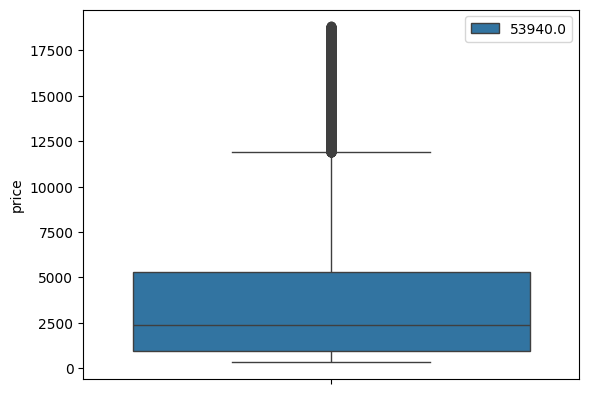

In [13]:
# I. Проведем небольшое исследование данных
# 1. Как варьируется цена 
sns.boxplot(data=diamonds, y="price")
display(diamonds['price'].describe())
plt.legend(diamonds['price'].describe())
plt.show()

count    53940.000000
mean         0.797940
std          0.474011
min          0.200000
25%          0.400000
50%          0.700000
75%          1.040000
max          5.010000
Name: carat, dtype: float64

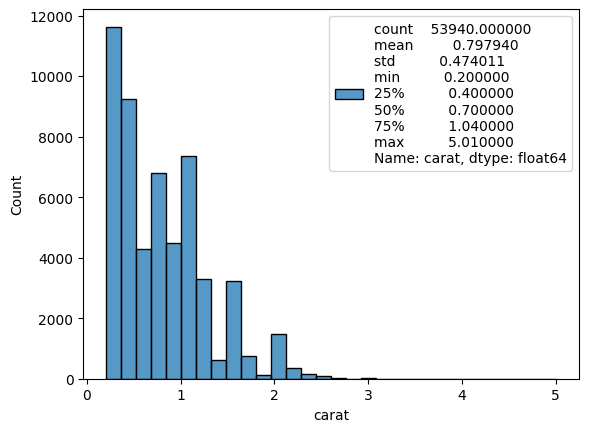

In [28]:
# 2. Как варьируется вес 
sns.histplot(data=diamonds, x="carat", bins=30)
display(diamonds['carat'].describe())
plt.legend([f"{diamonds['carat'].describe()}"])
plt.show()

In [27]:
# 3. Проверим наличие 0, отрицательных значений и NaN в датасете
display(diamonds[diamonds.isna().any(axis=1)])
display(diamonds.info())
display(diamonds[diamonds.x <= 0])

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,NaN
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,NaN
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,NaN
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,NaN
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,NaN
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,NaN,6.62,NaN
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,NaN,NaN,NaN
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,NaN
15951,1.14,Fair,G,VS1,57.5,67.0,6381,NaN,NaN,NaN
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53932 non-null  float64 
 8   y        53933 non-null  float64 
 9   z        53920 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


None

,carat,cut,color,clarity,depth,table,price,x,y,z


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,NaN
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,NaN
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,NaN
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,NaN
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,NaN
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,NaN,6.62,NaN
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,NaN,NaN,NaN
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,NaN
15951,1.14,Fair,G,VS1,57.5,67.0,6381,NaN,NaN,NaN
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,NaN


In [29]:
# Далее берем в работу только "правильные" значения
diamonds[['x','y','z']] = diamonds[['x','y','z']].replace(0, np.nan)
display(diamonds[diamonds[['x','y','z']].isna().any(axis=1)])

,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,NaN
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,NaN
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,NaN
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,NaN
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,NaN
11182,1.07,Ideal,F,SI2,61.6,56.0,4954,NaN,6.62,NaN
11963,1.00,Very Good,H,VS2,63.3,53.0,5139,NaN,NaN,NaN
13601,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,NaN
15951,1.14,Fair,G,VS1,57.5,67.0,6381,NaN,NaN,NaN
24394,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,NaN


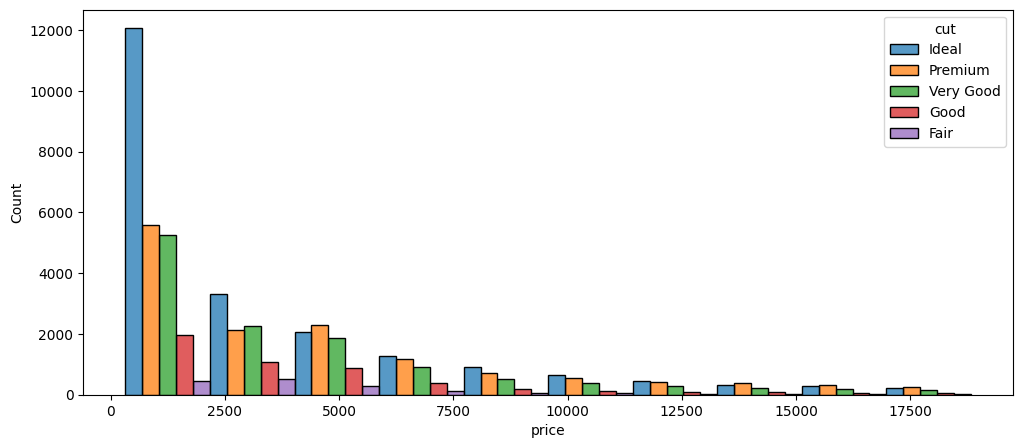

In [36]:
# II. Гистограмма распределения
# 1. Постройте гистограмму распределения цен.
# 2. Добавьте разделение по качеству огранки.
# 3. Сделайте вывод: у каких категорий огранки чаще встречаются дорогие камни?
plt.figure(figsize = (12, 5))
sns.histplot(data=diamonds, x="price", bins=10, hue="cut", multiple="dodge")
plt.show()

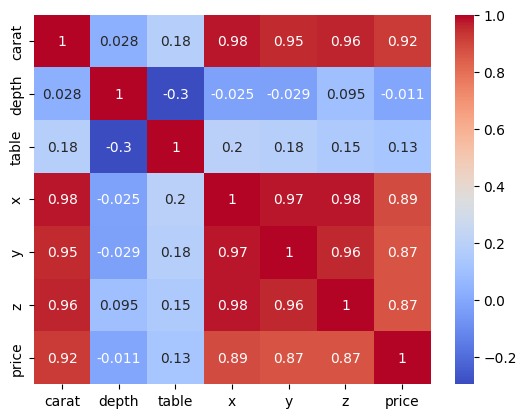

In [37]:
# III. Тепловая карта корреляций
# 1. Вычислите корреляцию между числовыми признаками (carat, depth, table, x, y, z, price).
# 2. Постройте sns.heatmap с подписями.
# 3. Сделайте вывод: какие характеристики сильнее всего связаны с ценой?

corr = diamonds[['carat', 'depth', 'table', 'x', 'y', 'z', 'price']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
# IV. Boxplot по цвету и чистоте
# 1. Сравните распределение цен (price) в зависимости от цвета бриллианта (color).
# 2. Сделайте вывод: какие категории цвета чаще всего ассоциируются с более высокой ценой?

# Q1 = diamonds.quantile(0.25)
# Q3 = diamonds.quantile(0.75)
# IQR = Q3 - Q1
# outliers = diamonds[(diamonds < Q1 - 1.5*IQR) | (diamonds > Q3 + 1.5*IQR)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=diamonds, x="clarity", y="price", hue='carat_cluster', )
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

TypeError: Unordered Categoricals can only compare equality or not

In [49]:
# diamonds['cluster'] = diamonds['carat'].apply(lambda x: 'легкий' if x < 0.5 else ('средний' if x < 1 else 'тяжелый'))
del diamonds['cluster']

In [50]:
diamonds['carat_cluster'] = pd.cut(
    diamonds['carat'],
    bins=5,
    labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large']
)

display(diamonds)

,carat,cut,color,clarity,depth,table,price,x,y,z,carat_cluster
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,Very Small
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,Very Small
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,Very Small
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,Very Small
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,Very Small
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,Very Small
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,Very Small
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,Very Small
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,Very Small


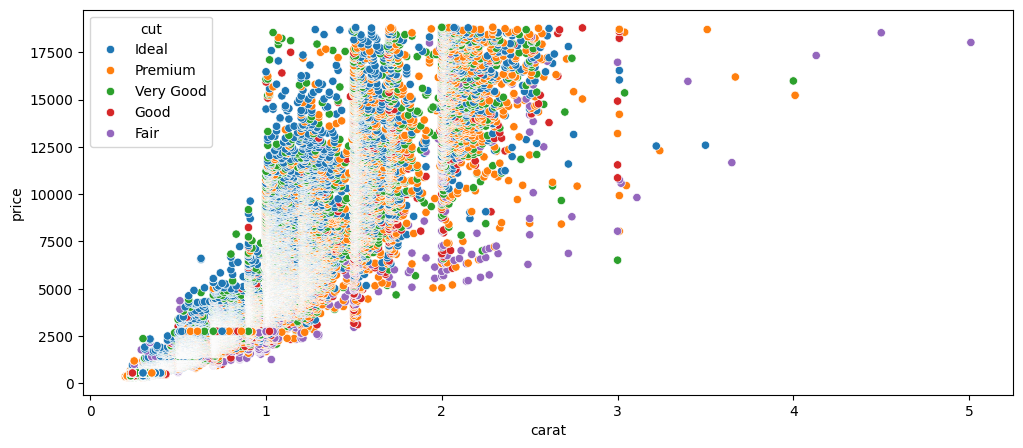

In [41]:
# V. Scatterplot: вес (карат) и цена
# 1. Постройте scatterplot для carat и price.
# 2. спользуйте hue="cut".
# 3. Сделайте вывод: как вес (каратность) связан с ценой, и есть ли отличие для разных категорий огранки?
plt.figure(figsize=(12, 5))
sns.scatterplot(data=diamonds, x="carat", y="price", hue="cut")
plt.show()

### <font color='teal'>Визуальный анализ факторов популярности видео на YouTube</font>
Датасет: Trending YouTube Video Statistics (Germany). <br>
Представьте, что вы аналитик в медиа-компании. <br>
Ваша задача — понять, какие факторы влияют на популярность видео (просмотры)?<br>
<i>Описание данных:</i>
- video_id
- views — количество просмотров
- likes — количество лайков
- dislikes — количество дизлайков (если есть в версии датасета)
- comment_count — количество комментариев
- title — название видео
- channel_title — название канала
- category_id — категория видео (например: музыка, спорт, новости)
- tags — теги видео
- publish_time — дата и время публикации видео
- trending_date — дата попадания в тренды
- thumbnail_link — ссылка на превью
- comments_disabled — отключены ли комментарии
- ratings_disabled — отключены ли лайки/дизлайки
- video_error_or_removed — удалено ли видео
- description - описание

In [69]:
# 1. Загрузка и подготовка данных 
# - Загрузите датасет
# - зучите структуру данных
df_videos = pd.read_csv('../data/Devideos.csv')
df_videos['views_mln'] = df_videos['views']/1e6
display(df_videos)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,views_mln
0,LgVi6y5QIjM,17.14.11,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13T17:08:49.000Z,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,1539,https://i.ytimg.com/vi/LgVi6y5QIjM/default.jpg,False,False,False,Heute gibt es mal wieder ein neues Format... w...,0.252786
1,Bayt7uQith4,17.14.11,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12T22:30:01.000Z,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,1278,https://i.ytimg.com/vi/Bayt7uQith4/default.jpg,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,0.797196
2,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97190,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John...",2.418783
3,AHtypnRk7JE,17.14.11,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12T15:00:01.000Z,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,1955,https://i.ytimg.com/vi/AHtypnRk7JE/default.jpg,False,False,False,в–єAlle Videos: http://bit.ly/1fa7Tw3\n\n\nвњљSnap...,0.380247
4,ZJ9We4bjcg0,17.14.11,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12T13:10:36.000Z,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,10244,https://i.ytimg.com/vi/ZJ9We4bjcg0/default.jpg,False,False,False,18 Song Mashup Гјber den (verГ¤nderten) Beat von...,0.822213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40835,fn5WNxy-Wcw,18.14.06,KINGDOM HEARTS III вЂ“ E3 2018 Pirates of the Ca...,Kingdom Hearts,20,2018-06-12T01:54:02.000Z,"Kingdom Hearts|""KH3""|""Kingdom Hearts 3""|""Pirat...",1394530,46778,501,9878,https://i.ytimg.com/vi/fn5WNxy-Wcw/default.jpg,False,False,False,Find out more about Kingdom Hearts 3: https://...,1.394530
40836,zAFv43lxqHE,18.14.06,YMS: The Visit,YourMovieSucksDOTorg,24,2018-06-13T21:58:43.000Z,[none],139733,11155,119,1968,https://i.ytimg.com/vi/zAFv43lxqHE/default.jpg,False,False,False,Patreon: http://www.patreon.com/YMSTwitch: htt...,0.139733
40837,zSXG5I6Y2fA,18.14.06,Ungut umgeschult вЂ“ GrГјnwald als Ersthelfer am ...,GrГјnwald Freitagscomedy,24,2018-06-12T10:01:28.000Z,"GГјnter GrГјnwald|""GrГјnwald Freitagscomedy""|""GГјn...",26054,364,11,8,https://i.ytimg.com/vi/zSXG5I6Y2fA/default.jpg,False,False,False,GГјnter versucht sich als Ersthelfer bei einem ...,0.026054
40838,5d115sePmaU,18.14.06,Assassin's Creed Odyssey: E3 2018 Welt-EnthГјll...,Assassin's Creed DE,20,2018-06-11T21:16:55.000Z,"Assassin's Creed|""Assassins Creed""|""Assassin's...",1139198,14900,1421,1587,https://i.ytimg.com/vi/5d115sePmaU/default.jpg,False,False,False,"Vom verstoГџenen SГ¶ldner zum legendГ¤ren Helden,...",1.139198


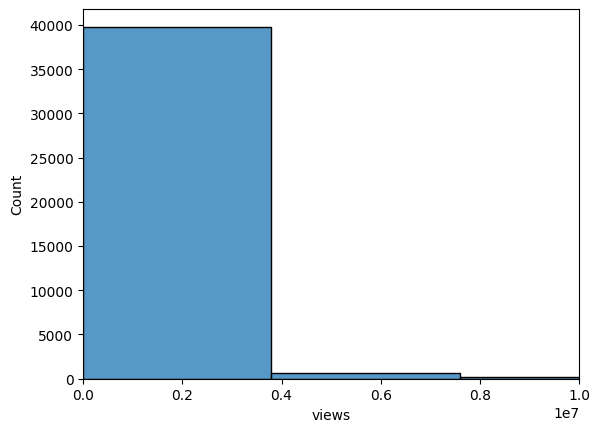

In [64]:
# 2. Распределение просмотров
# Постройте гистограмму распределения views.
sns.histplot(data=df_videos, x="views", bins=30)
plt.xlim(0, 10e6)
plt.show()

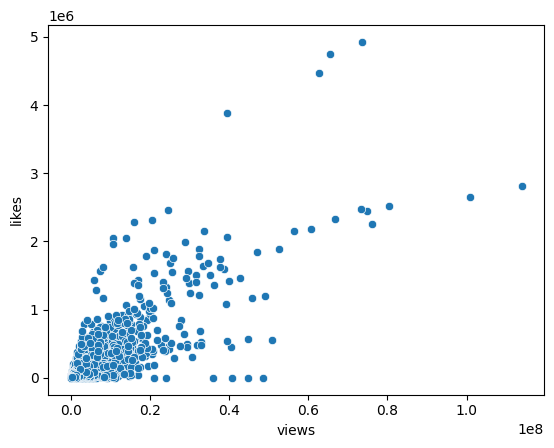

In [58]:
# 3. Связь просмотров и лайков
# Постройте scatter plot (views vs likes).
sns.scatterplot(data=df_videos, x="views", y="likes")
plt.show()

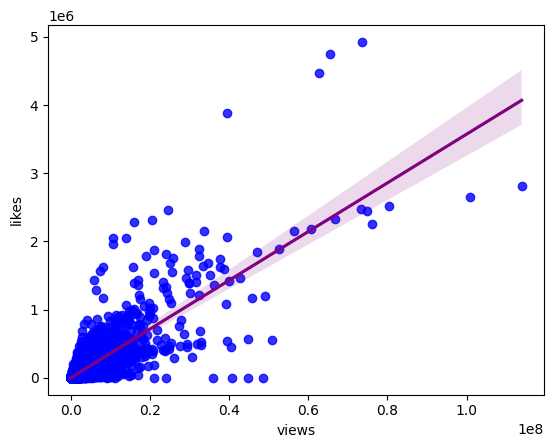

In [60]:
# 4. Добавьте линию регрессии
# спользуйте regplot.
sns.regplot(data=df_videos, x="views", y="likes", scatter_kws={"color": "blue"}, line_kws={"color": "purple"})
plt.show()

In [87]:
df_categories = df_videos[df_videos['category_id'].isnull() == False]
# display(df_categories)
Q1 = df_categories['views_mln'].quantile(0.25)
Q3 = df_categories['views_mln'].quantile(0.75)
IQR = Q3 - Q1

df_categories_no_outliers = df_categories[
    (df_categories['views_mln'] >= Q1 - 1.5 * IQR) &
    (df_categories['views_mln'] <= Q3 + 1.5 * IQR)
]
display(df_categories_no_outliers)

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,views_mln
0,LgVi6y5QIjM,17.14.11,Sing zu Ende! | Gesangseinlagen vom Feinsten |...,inscope21,24,2017-11-13T17:08:49.000Z,"inscope21|""sing zu ende""|""gesangseinlagen""|""ge...",252786,35885,230,1539,https://i.ytimg.com/vi/LgVi6y5QIjM/default.jpg,False,False,False,Heute gibt es mal wieder ein neues Format... w...,0.252786
1,Bayt7uQith4,17.14.11,Kinder ferngesteuert im Kiosk! Erwachsene abzo...,LUKE! Die Woche und ich,23,2017-11-12T22:30:01.000Z,"Kinder|""ferngesteuert""|""Kinder ferngesteuert""|...",797196,53576,302,1278,https://i.ytimg.com/vi/Bayt7uQith4/default.jpg,False,False,False,Kinder ferngesteuert! Kinder lassen sich sooo ...,0.797196
3,AHtypnRk7JE,17.14.11,Das Fermi-Paradoxon,100SekundenPhysik,27,2017-11-12T15:00:01.000Z,"Physik|""Wissenschaft""|""Technik""|""Science-Ficti...",380247,31821,458,1955,https://i.ytimg.com/vi/AHtypnRk7JE/default.jpg,False,False,False,в–єAlle Videos: http://bit.ly/1fa7Tw3\n\n\nвњљSnap...,0.380247
4,ZJ9We4bjcg0,17.14.11,18 SONGS mit Kelly MissesVlog (Sing-off),rezo,24,2017-11-12T13:10:36.000Z,"kelly|""missesvlog""|""kelly song""|""bausa""|""bausa...",822213,100684,2467,10244,https://i.ytimg.com/vi/ZJ9We4bjcg0/default.jpg,False,False,False,18 Song Mashup Гјber den (verГ¤nderten) Beat von...,0.822213
5,xapGFgWqtg4,17.14.11,Geld verdienen mit Online-Umfragen? Geht das w...,Die Allestester,22,2017-11-13T01:49:24.000Z,[none],32709,3093,296,63,https://i.ytimg.com/vi/xapGFgWqtg4/default.jpg,False,False,False,Wir haben Meinungsstudie.de (в–є http://bit.ly/2...,0.032709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40833,C9DCE3k2lWA,18.14.06,Ш§Щ„Ш±Ш¦ЩЉШі ШЈШ­Щ…ШЇ ШЈШ­Щ…ШЇ ЩЉШµШ±Ш­ ШЁШЈЩ†Щ‡ ШЄЩ„Щ‚Щ‰ ШЄЩ‡ШЇЩЉШЇШ§ШЄ Щ€ЩЉШЄШ­ШіШ±...,Shahid TV,17,2018-06-13T19:31:05.000Z,"Ш§Щ„Ш±Ш¦ЩЉШі|""ШЈШ­Щ…ШЇ""|""ЩЉШµШ±Ш­""|""ШЁШЈЩ†Щ‡""|""ШЄЩ„Щ‚Щ‰""|""ШЄЩ‡ШЇЩЉШЇШ§ШЄ""|""...",184242,1440,97,470,https://i.ytimg.com/vi/C9DCE3k2lWA/default.jpg,False,False,False,Ш§Щ„Ш±Ш¦ЩЉШі ШЈШ­Щ…ШЇ ШЈШ­Щ…ШЇ ЩЉШµШ±Ш­ ШЁШЈЩ†Щ‡ ШЄЩ„Щ‚Щ‰ ШЄЩ‡ШЇЩЉШЇШ§ШЄ Щ€ЩЉШЄШ­ШіШ±...,0.184242
40834,KYke3FFiyk4,18.14.06,Crime Patrol Dial 100 - Ep 796 - Full Episode ...,SET India,24,2018-06-13T13:54:47.000Z,"true events|""sony entertainment channel""|""cons...",54395,285,61,37,https://i.ytimg.com/vi/KYke3FFiyk4/default.jpg,False,False,False,Click here to subscribe to SonyLIV : http://w...,0.054395
40836,zAFv43lxqHE,18.14.06,YMS: The Visit,YourMovieSucksDOTorg,24,2018-06-13T21:58:43.000Z,[none],139733,11155,119,1968,https://i.ytimg.com/vi/zAFv43lxqHE/default.jpg,False,False,False,Patreon: http://www.patreon.com/YMSTwitch: htt...,0.139733
40837,zSXG5I6Y2fA,18.14.06,Ungut umgeschult вЂ“ GrГјnwald als Ersthelfer am ...,GrГјnwald Freitagscomedy,24,2018-06-12T10:01:28.000Z,"GГјnter GrГјnwald|""GrГјnwald Freitagscomedy""|""GГјn...",26054,364,11,8,https://i.ytimg.com/vi/zSXG5I6Y2fA/default.jpg,False,False,False,GГјnter versucht sich als Ersthelfer bei einem ...,0.026054


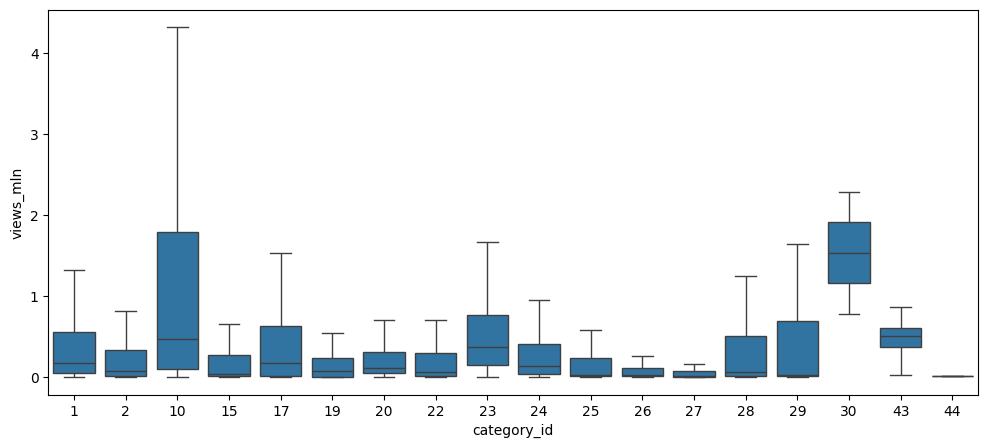

In [90]:
# 5. Популярность категорий (category vs views)
# Постройте boxplot или violin plot
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_videos, x="category_id", y="views_mln", showfliers=False)
plt.show()

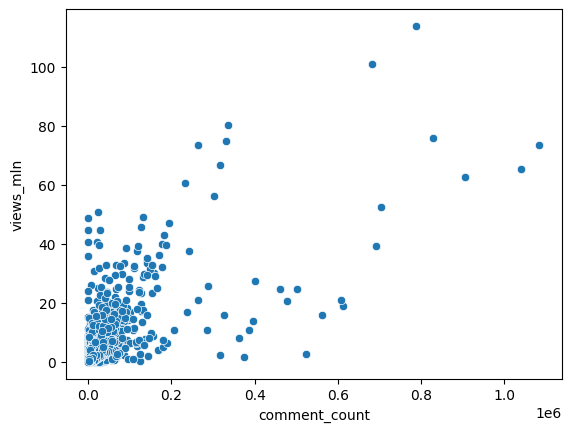

In [82]:
# 6. Влияние комментариев (comment_count vs views)
sns.scatterplot(data=df_videos, x="comment_count", y="views_mln")
plt.show()

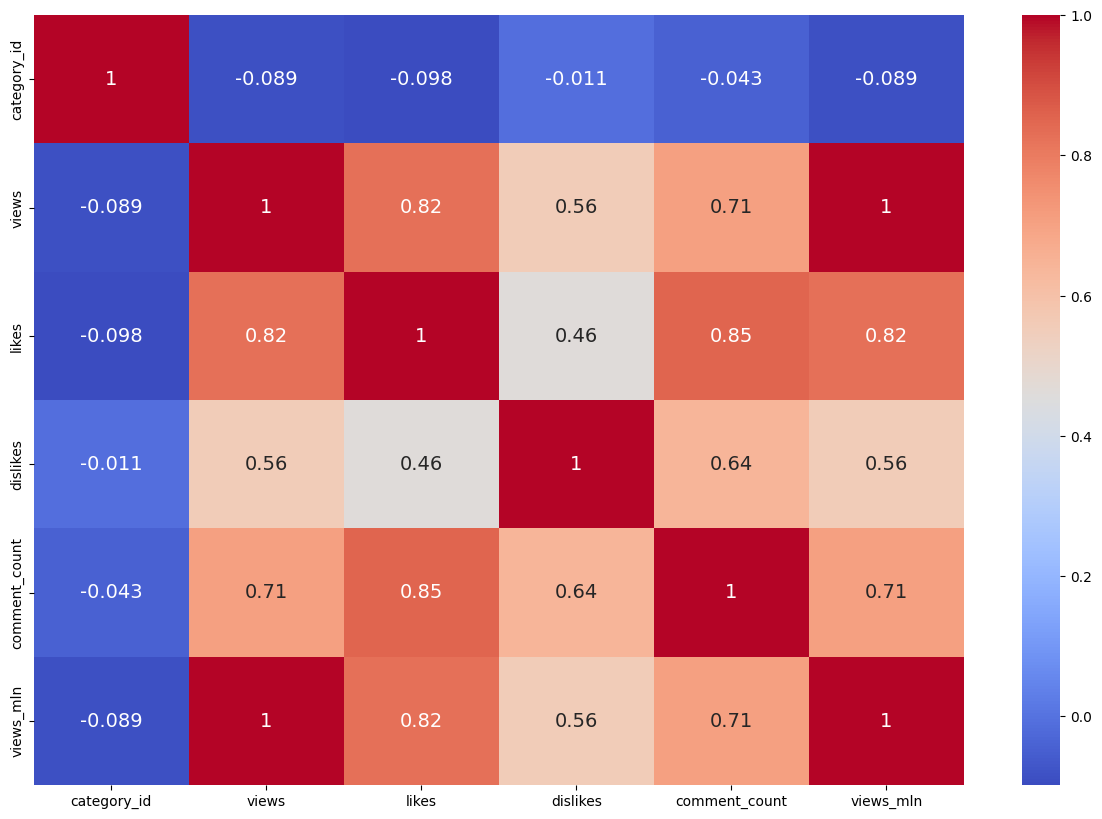

In [95]:
# 7. Корреляционная матрица
# Постройте heatmap по числовым признакам.
plt.figure(figsize=(15, 10))
sns.heatmap(df_videos.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", annot_kws={"size": 14})
plt.show()